In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")

In [3]:
df = pd.read_csv('car_price_prediction_.csv')
display(df.head())
df.info()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang


<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car ID        2500 non-null   int64  
 1   Brand         2500 non-null   str    
 2   Year          2500 non-null   int64  
 3   Engine Size   2500 non-null   float64
 4   Fuel Type     2500 non-null   str    
 5   Transmission  2500 non-null   str    
 6   Mileage       2500 non-null   int64  
 7   Condition     2500 non-null   str    
 8   Price         2500 non-null   float64
 9   Model         2500 non-null   str    
dtypes: float64(2), int64(3), str(5)
memory usage: 266.2 KB


In [4]:
# Data Cleaning
print("Missing values in each column:\n", df.isnull().sum())
print("\nNumber of duplicated rows:", df.duplicated().sum())

# Describe numerical features
df.describe()

Missing values in each column:
 Car ID          0
Brand           0
Year            0
Engine Size     0
Fuel Type       0
Transmission    0
Mileage         0
Condition       0
Price           0
Model           0
dtype: int64

Number of duplicated rows: 0


,Car ID,Year,Engine Size,Mileage,Price
count,2500.00000,2500.0000,2500.000000,2500.000000,2500.000000
mean,1250.50000,2011.6268,3.465240,149749.844800,52638.022532
std,721.83216,6.9917,1.432053,87919.952034,27295.833455
min,1.00000,2000.0000,1.000000,15.000000,5011.270000
25%,625.75000,2005.0000,2.200000,71831.500000,28908.485000
50%,1250.50000,2012.0000,3.400000,149085.000000,53485.240000
75%,1875.25000,2018.0000,4.700000,225990.500000,75838.532500
max,2500.00000,2023.0000,6.000000,299967.000000,99982.590000


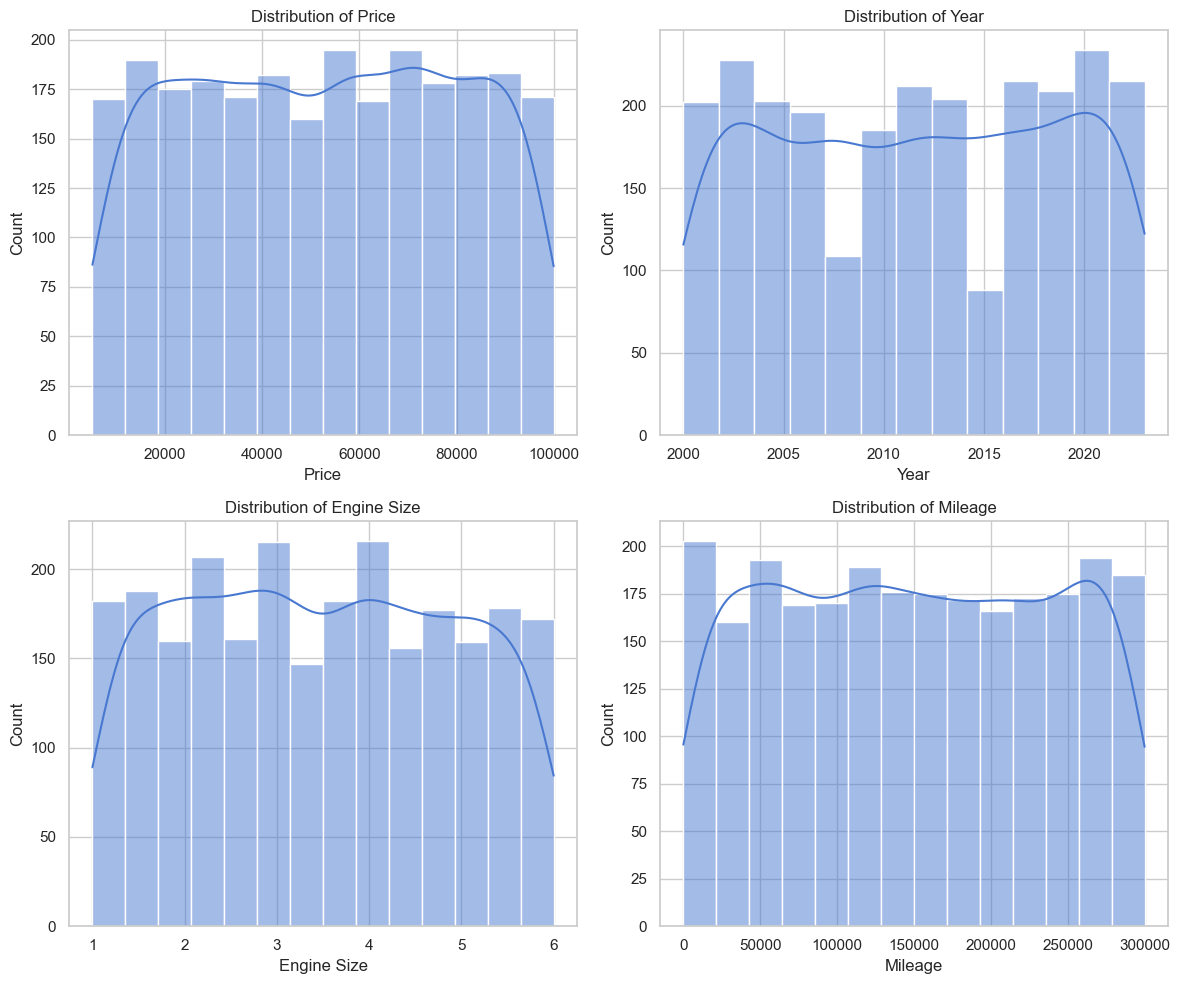

In [5]:
# Univariate Analysis (Numerical)
numerical_cols = ['Price', 'Year', 'Engine Size', 'Mileage']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for idx, col in enumerate(numerical_cols):
    row, col_idx = idx // 2, idx % 2
    sns.histplot(df[col], kde=True, ax=axes[row, col_idx])
    axes[row, col_idx].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

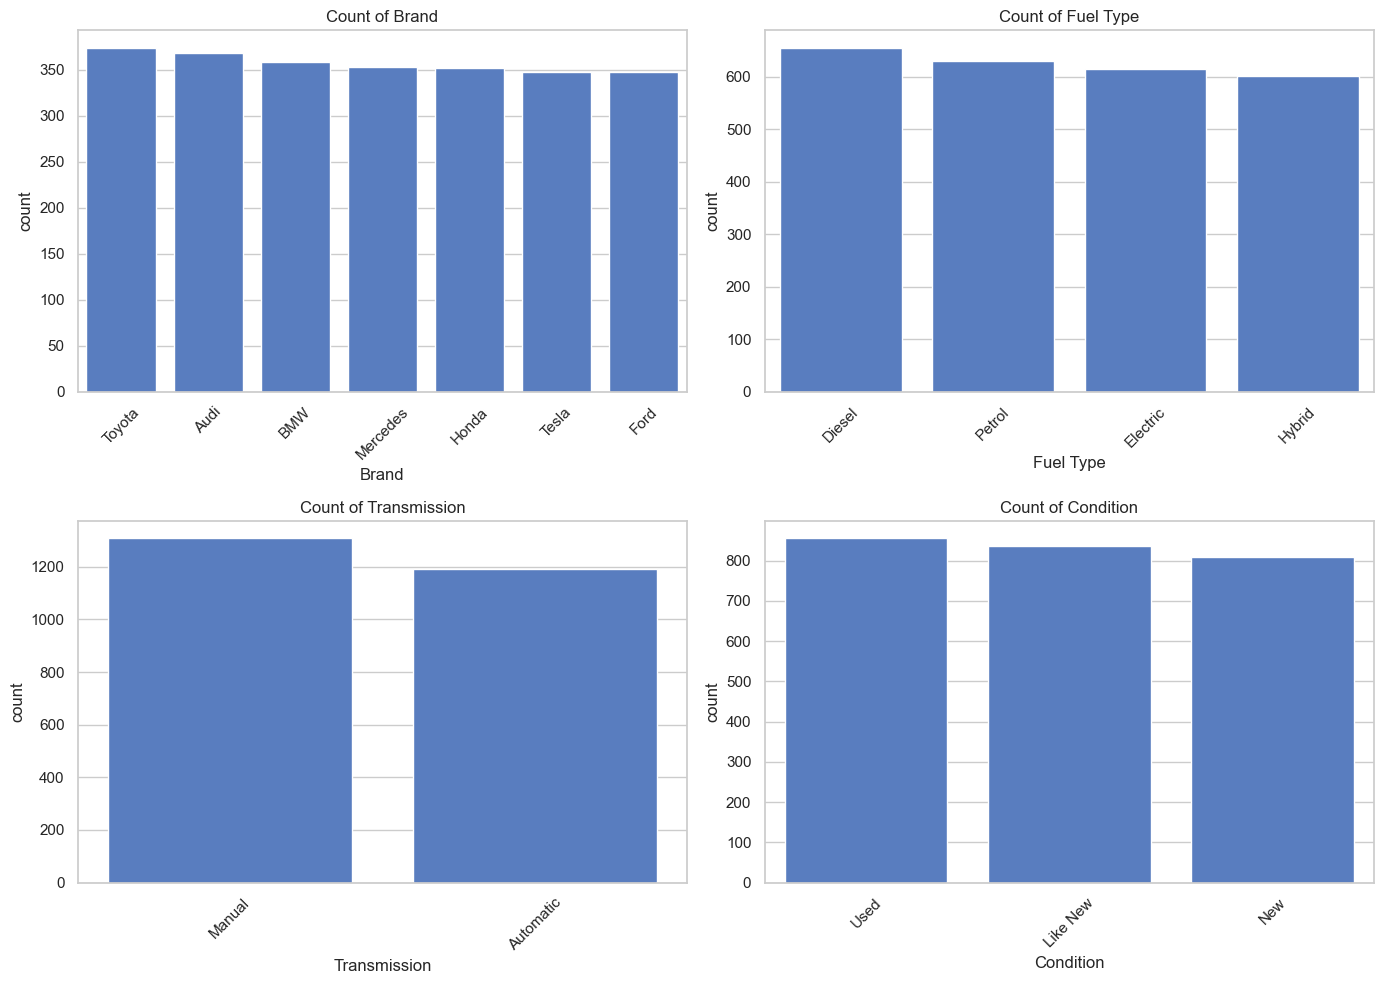

In [6]:
# Univariate Analysis (Categorical)
categorical_cols = ['Brand', 'Fuel Type', 'Transmission', 'Condition']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for idx, col in enumerate(categorical_cols):
    row, col_idx = idx // 2, idx % 2
    sns.countplot(data=df, x=col, ax=axes[row, col_idx], order=df[col].value_counts().index)
    axes[row, col_idx].set_title(f'Count of {col}')
    axes[row, col_idx].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

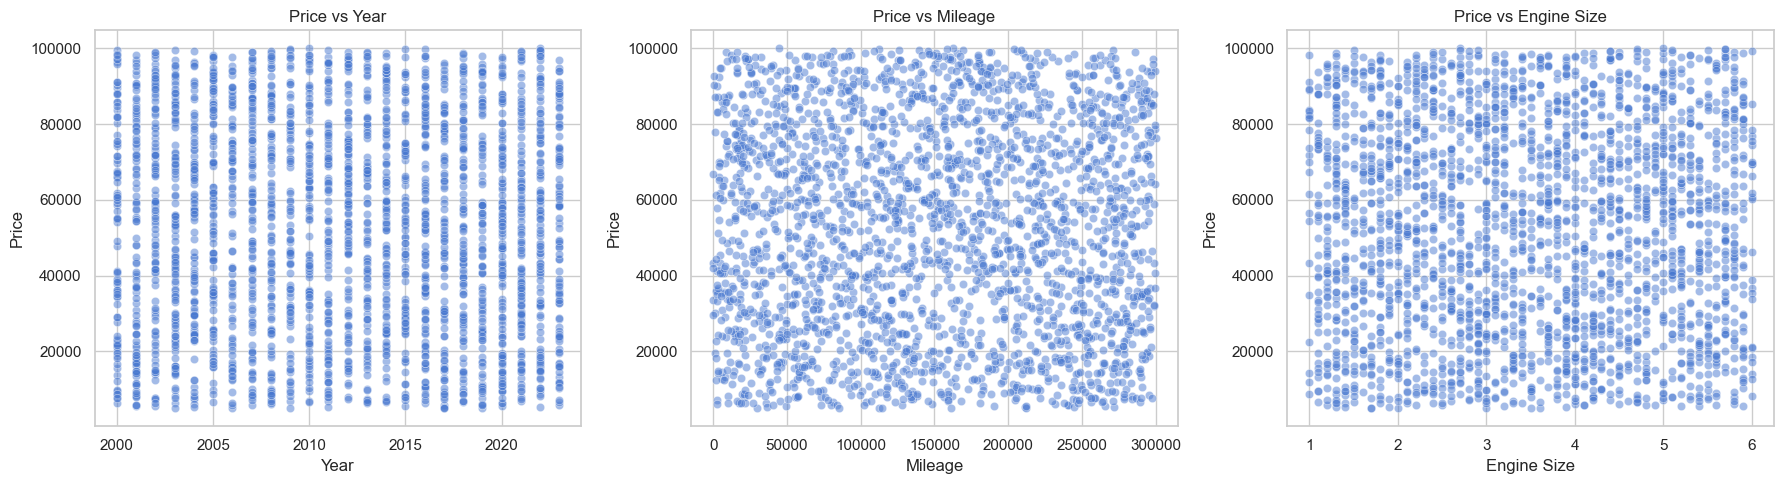

In [7]:
# Bivariate Analysis (Numerical vs Target)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(data=df, x='Year', y='Price', ax=axes[0], alpha=0.5)
axes[0].set_title('Price vs Year')
sns.scatterplot(data=df, x='Mileage', y='Price', ax=axes[1], alpha=0.5)
axes[1].set_title('Price vs Mileage')
sns.scatterplot(data=df, x='Engine Size', y='Price', ax=axes[2], alpha=0.5)
axes[2].set_title('Price vs Engine Size')
plt.tight_layout()
plt.show()

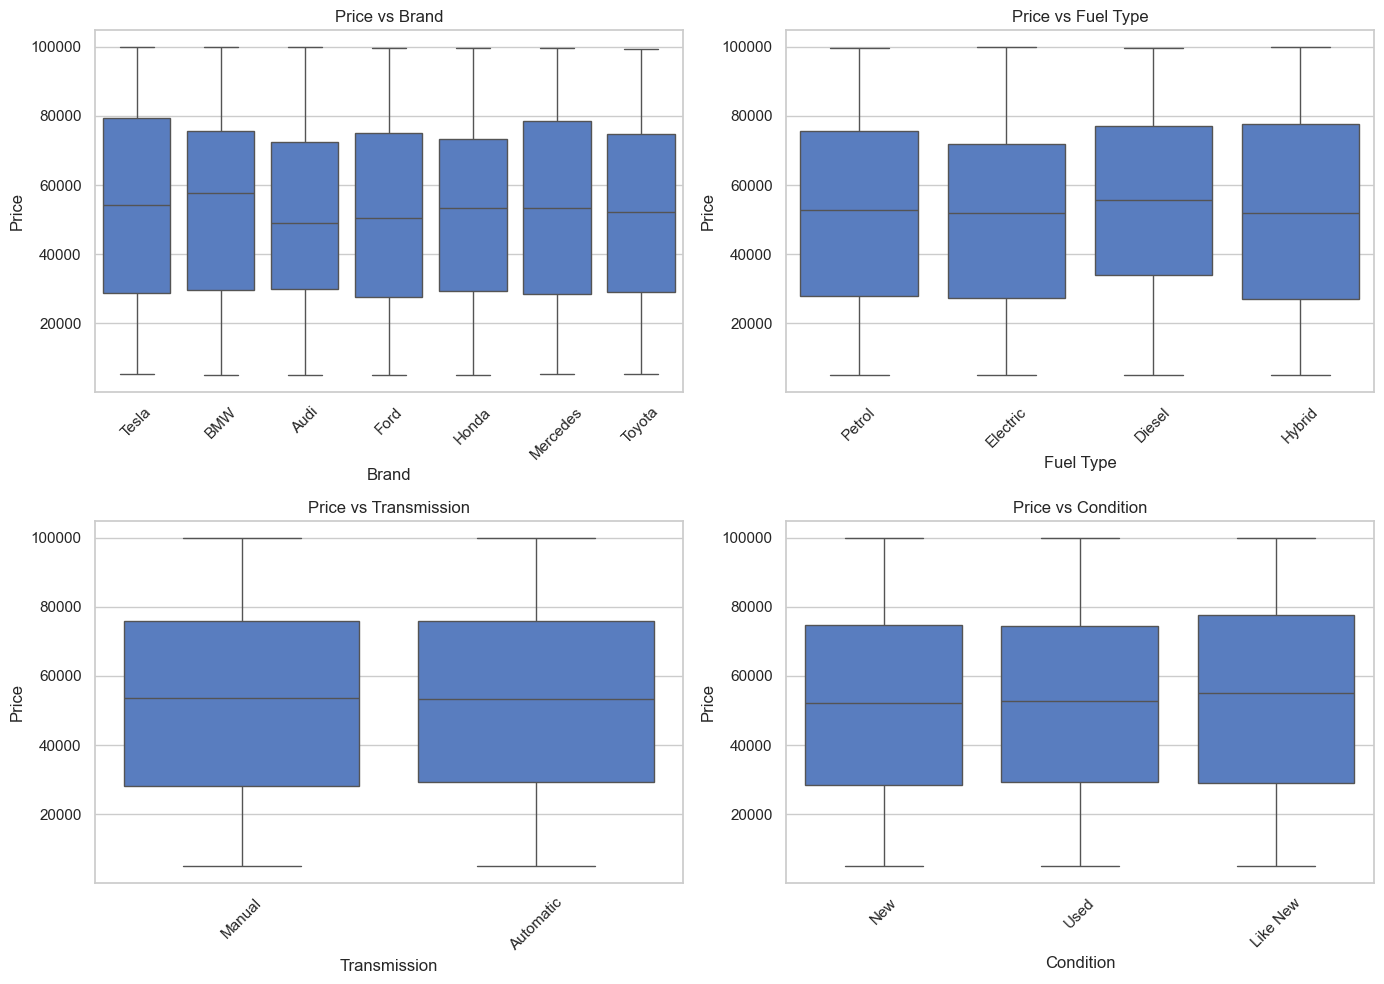

In [8]:
# Bivariate Analysis (Categorical vs Target)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for idx, col in enumerate(categorical_cols):
    row, col_idx = idx // 2, idx % 2
    sns.boxplot(data=df, x=col, y='Price', ax=axes[row, col_idx])
    axes[row, col_idx].set_title(f'Price vs {col}')
    axes[row, col_idx].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

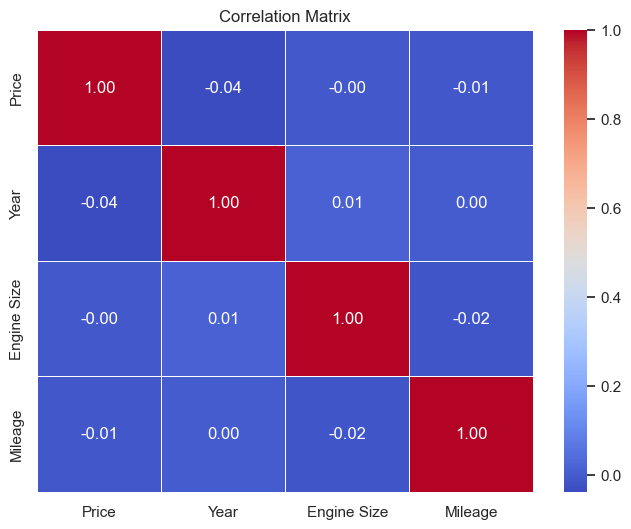

In [9]:
# Correlation Analysis
plt.figure(figsize=(8, 6))
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

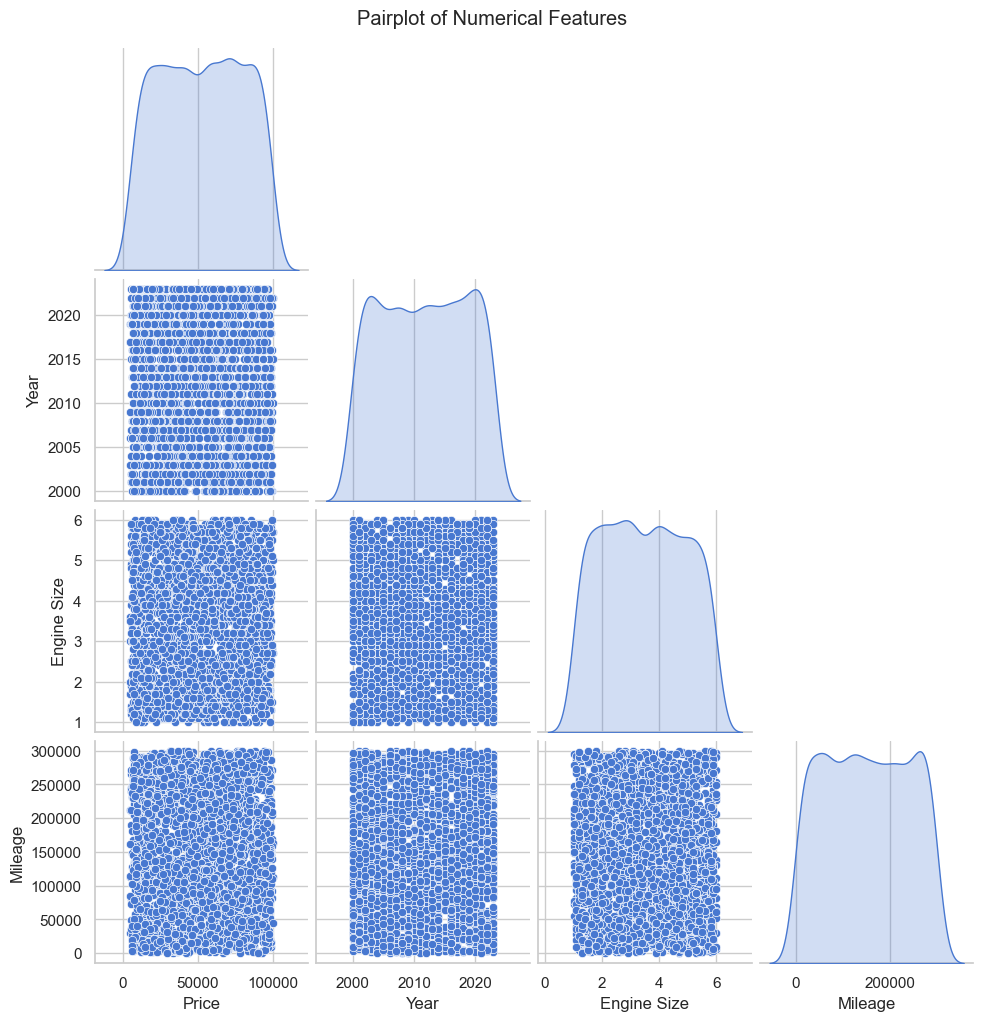

In [10]:
# Pairplot for numerical features
sns.pairplot(df[numerical_cols], diag_kind='kde', corner=True)
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

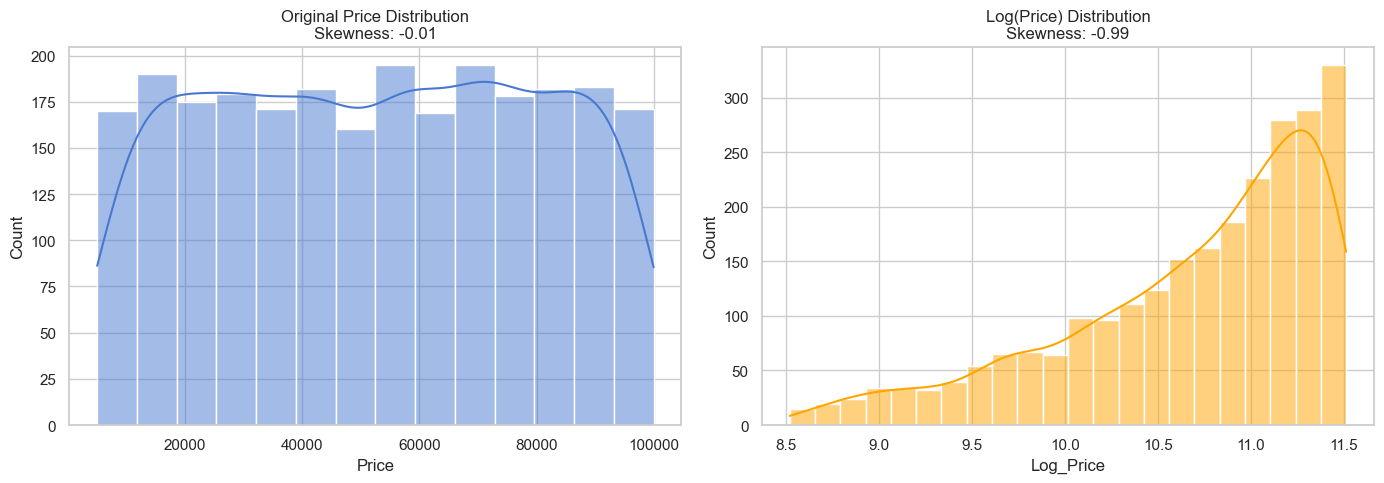

In [11]:
# 1. Target Variable Deep-Dive (Skewness & Log Transformation)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original Price Distribution
sns.histplot(df['Price'], kde=True, ax=axes[0])
axes[0].set_title(f"Original Price Distribution\nSkewness: {df['Price'].skew():.2f}")

# Log Transformed Price Distribution
df['Log_Price'] = np.log1p(df['Price'])
sns.histplot(df['Log_Price'], kde=True, ax=axes[1], color='orange')
axes[1].set_title(f"Log(Price) Distribution\nSkewness: {df['Log_Price'].skew():.2f}")

plt.tight_layout()
plt.show()

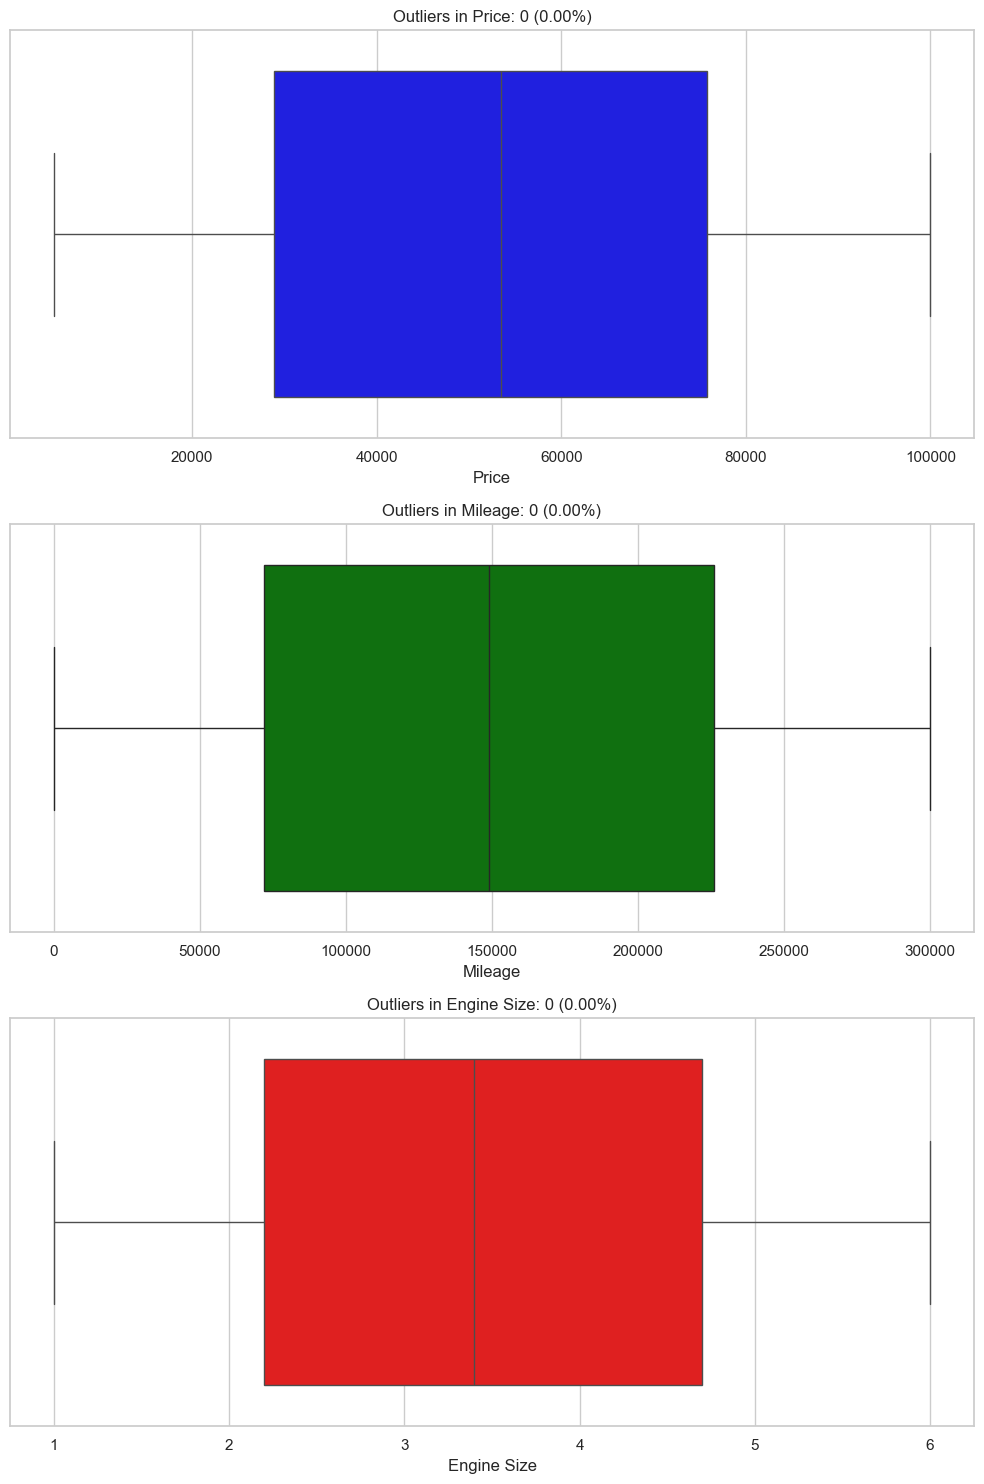

In [12]:
# 2. Outlier Detection
fig, axes = plt.subplots(3, 1, figsize=(10, 15))

# Identify continuous features representing range values
features_to_check = ['Price', 'Mileage', 'Engine Size']
colors = ['blue', 'green', 'red']

for idx, feature in enumerate(features_to_check):
    sns.boxplot(x=df[feature], ax=axes[idx], color=colors[idx])
    
    # Calculate IQR for the feature
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
    outlier_pct = len(outliers) / len(df) * 100
    
    axes[idx].set_title(f"Outliers in {feature}: {len(outliers)} ({outlier_pct:.2f}%)")

plt.tight_layout()
plt.show()

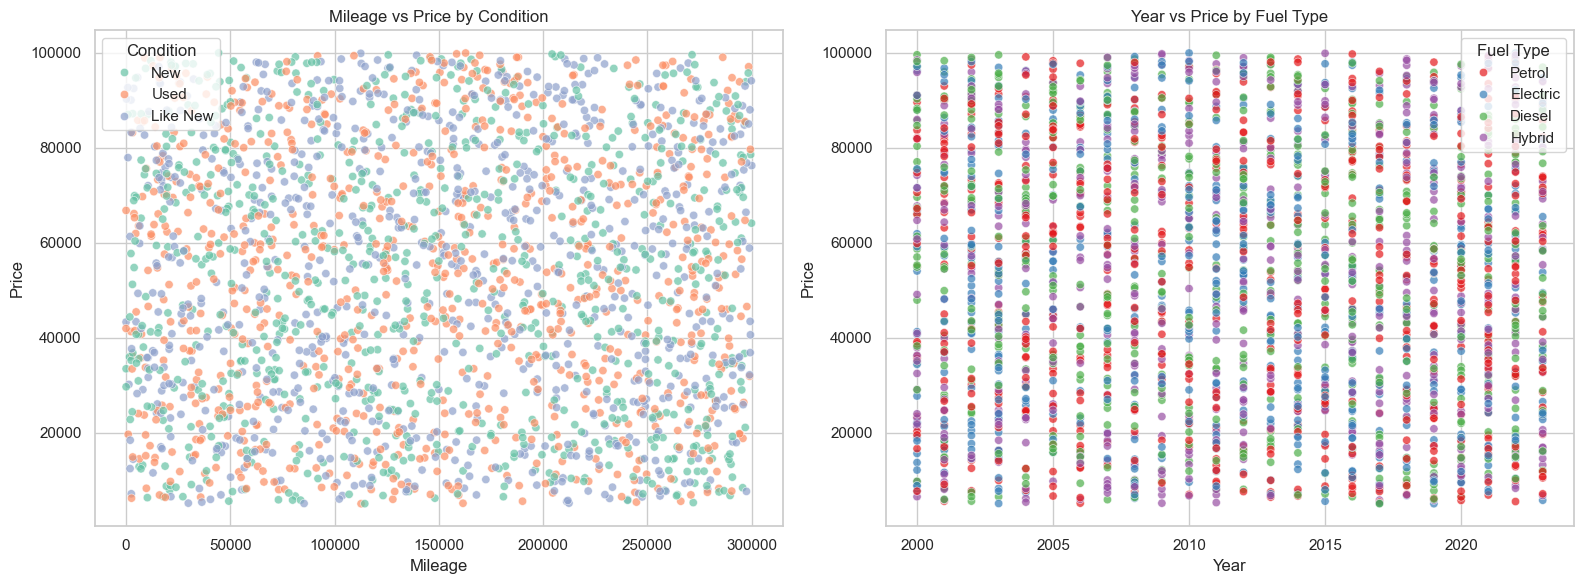

In [13]:
# 3. Multivariate Analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Mileage vs Price separated by Conditon
sns.scatterplot(data=df, x='Mileage', y='Price', hue='Condition', palette='Set2', alpha=0.7, ax=axes[0])
axes[0].set_title('Mileage vs Price by Condition')

# Year vs Price separated by Fuel Type
sns.scatterplot(data=df, x='Year', y='Price', hue='Fuel Type', palette='Set1', alpha=0.7, ax=axes[1])
axes[1].set_title('Year vs Price by Fuel Type')

plt.tight_layout()
plt.show()

### Key EDA Insights & Next Steps

Based on the Exploratory Data Analysis above, here are the primary takeaways:

**1. Data Linearity & Correlations**
*   **Weak Linear Relationships:** The correlation matrix and scatter plots reveal that continuous features like `Year`, `Engine Size`, and `Mileage` have near-zero or very weak linear correlation with `Price`. In a real-world scenario, you would expect a strong negative correlation between `Mileage` and `Price`, and a strong positive correlation between `Year` and `Price`. Here, they appear as largely scattered, random clouds.

**2. Distribution Patterns**
*   **Lack of Skewness:** Real-world price data is typically heavily right-skewed. However, the histograms show that `Price`, `Mileage`, and `Engine Size` are relatively evenly distributed. The `log(Price)` transformation doesn't drastically change the shape of the data because there isn't a long tail.
*   **Few to No Outliers:** The IQR-based outlier detection boxplots show very few outliers across `Price`, `Mileage`, and `Engine Size`, reinforcing that the numeric data lacks extreme variations.

**3. Categorical Variables Impact**
*   **Overlapping Price Ranges:** The boxplots for categorical features (`Brand`, `Fuel Type`, `Transmission`, and `Condition`) show heavily overlapping Interquartile Ranges (IQRs). This indicates that no single category (e.g., being "New" vs "Used", or "Automatic" vs "Manual") holds a definitive premium on the price.

**4. Data Anomalies / Synthetic Nature**
*   Looking closely at the scatter records and combinations (e.g., extremely high mileage on new cars or manual electric vehicles), it strongly indicates the dataset is **synthetically generated or randomized** rather than scraped from real-world listings.

**Next Steps for Modeling:**
Because there are no strong linear correlations, simple models like Linear Regression will likely perform poorly (low R² score). To get accurate predictions on this dataset, modeling should rely on non-linear models capable of capturing complex interactions, such as:
*   Random Forests
*   Gradient Boosting (XGBoost/LightGBM)
*   Neural Networks

## Implementation: Feature Engineering and Internet Enrichment

This section adds stronger engineered features from the existing dataset and enriches with free public internet data sources. It does not train or evaluate any model.

In [14]:
# 4. Feature Engineering 
df_features = df.copy()

reference_year = int(max(pd.Timestamp.today().year, df_features['Year'].max()))
df_features['car_age'] = (reference_year - df_features['Year']).clip(lower=0)
df_features['age_squared'] = df_features['car_age'] ** 2
df_features['log_mileage'] = np.log1p(df_features['Mileage'])

age_denominator = df_features['car_age'].replace(0, 1)
df_features['mileage_per_year'] = (df_features['Mileage'] / age_denominator).round(2)

condition_map = {'Used': 1, 'Like New': 2, 'New': 3}
df_features['condition_score'] = df_features['Condition'].map(condition_map).fillna(0).astype(int)

df_features['brand_model'] = df_features['Brand'].astype(str) + '_' + df_features['Model'].astype(str)
df_features['fuel_transmission'] = df_features['Fuel Type'].astype(str) + '_' + df_features['Transmission'].astype(str)

df_features['mileage_bin'] = pd.qcut(df_features['Mileage'], q=4, duplicates='drop').astype(str)
df_features['engine_size_bin'] = pd.cut(
    df_features['Engine Size'],
    bins=[0, 1.6, 2.5, 3.5, 5.0, np.inf],
    labels=['tiny', 'small', 'mid', 'large', 'very_large'],
    include_lowest=True
).astype(str)

df_features['condition_mileage_bin'] = (
    df_features['Condition'].astype(str) + '_' + df_features['mileage_bin'].astype(str)
)

df_features['new_high_mileage_flag'] = (
    (df_features['Condition'].eq('New')) & (df_features['Mileage'] > 50000)
).astype(int)
df_features['ev_engine_size_mismatch_flag'] = (
    (df_features['Fuel Type'].eq('Electric')) & (df_features['Engine Size'] > 0.1)
).astype(int)
df_features['manual_ev_flag'] = (
    (df_features['Fuel Type'].eq('Electric')) & (df_features['Transmission'].eq('Manual'))
).astype(int)

preview_cols = [
    'Brand', 'Model', 'Year', 'Mileage', 'Fuel Type', 'Transmission',
    'car_age', 'mileage_per_year', 'condition_score',
    'new_high_mileage_flag', 'ev_engine_size_mismatch_flag', 'manual_ev_flag'
]
display(df_features[preview_cols].head())

print('Engineered features created:', 12)
print('New + high mileage flags:', int(df_features['new_high_mileage_flag'].sum()))
print('Electric + engine-size mismatch flags:', int(df_features['ev_engine_size_mismatch_flag'].sum()))
print('Manual EV flags:', int(df_features['manual_ev_flag'].sum()))

,Brand,Model,Year,Mileage,Fuel Type,Transmission,car_age,mileage_per_year,condition_score,new_high_mileage_flag,ev_engine_size_mismatch_flag,manual_ev_flag
0,Tesla,Model X,2016,114832,Petrol,Manual,10,11483.20,3,1,0,0
1,BMW,5 Series,2018,143190,Electric,Manual,8,17898.75,1,0,1,1
2,Audi,A4,2013,181601,Electric,Manual,13,13969.31,3,1,1,1
3,Tesla,Model Y,2011,68682,Diesel,Automatic,15,4578.80,3,1,0,0
4,Ford,Mustang,2009,223009,Diesel,Manual,17,13118.18,2,0,0,0


Engineered features created: 12
New + high mileage flags: 660
Electric + engine-size mismatch flags: 614
Manual EV flags: 323


In [15]:
# 5. Internet Feature Sources (Free Public Data, AU-focused proxies)
import requests

def fetch_open_meteo_yearly_features(start_year, end_year, latitude=-37.8136, longitude=144.9631):
    columns = ['Year', 'weather_temp_avg_c', 'weather_precip_total_mm']
    url = 'https://archive-api.open-meteo.com/v1/archive'
    params = {
        'latitude': latitude,
        'longitude': longitude,
        'start_date': f'{start_year}-01-01',
        'end_date': f'{end_year}-12-31',
        'daily': 'temperature_2m_mean,precipitation_sum',
        'timezone': 'Australia/Melbourne'
    }
    try:
        response = requests.get(url, params=params, timeout=20)
        response.raise_for_status()
        payload = response.json()
        daily = payload.get('daily', {})

        weather_df = pd.DataFrame({
            'date': pd.to_datetime(daily.get('time', []), errors='coerce'),
            'temp_avg_c': pd.to_numeric(daily.get('temperature_2m_mean', []), errors='coerce'),
            'precip_mm': pd.to_numeric(daily.get('precipitation_sum', []), errors='coerce')
        }).dropna(subset=['date'])

        if weather_df.empty:
            return pd.DataFrame(columns=columns)

        weather_df['Year'] = weather_df['date'].dt.year
        yearly_weather = weather_df.groupby('Year', as_index=False).agg(
            weather_temp_avg_c=('temp_avg_c', 'mean'),
            weather_precip_total_mm=('precip_mm', 'sum')
        )
        return yearly_weather[columns]
    except Exception as exc:
        print(f'Open-Meteo fetch failed: {exc}')
        return pd.DataFrame(columns=columns)

def fetch_brent_oil_yearly_features():
    columns = ['Year', 'brent_oil_usd_per_barrel']
    url = 'https://fred.stlouisfed.org/graph/fredgraph.csv?id=DCOILBRENTEU'
    try:
        oil_df = pd.read_csv(url)
        oil_df['DATE'] = pd.to_datetime(oil_df['DATE'], errors='coerce')
        oil_df['DCOILBRENTEU'] = pd.to_numeric(oil_df['DCOILBRENTEU'], errors='coerce')
        oil_df = oil_df.dropna(subset=['DATE', 'DCOILBRENTEU'])

        if oil_df.empty:
            return pd.DataFrame(columns=columns)

        oil_df['Year'] = oil_df['DATE'].dt.year
        yearly_oil = oil_df.groupby('Year', as_index=False)['DCOILBRENTEU'].mean()
        yearly_oil = yearly_oil.rename(columns={'DCOILBRENTEU': 'brent_oil_usd_per_barrel'})
        return yearly_oil[columns]
    except Exception as exc:
        print(f'Brent oil fetch failed: {exc}')
        return pd.DataFrame(columns=columns)

def fetch_au_cpi_yearly_features():
    columns = ['Year', 'au_cpi_index']
    url = 'https://api.worldbank.org/v2/country/AUS/indicator/FP.CPI.TOTL?format=json&per_page=2000'
    try:
        response = requests.get(url, timeout=20)
        response.raise_for_status()
        payload = response.json()
        records = payload[1] if isinstance(payload, list) and len(payload) > 1 else []

        rows = []
        for rec in records:
            year = rec.get('date')
            value = rec.get('value')
            if year is None or value is None:
                continue
            rows.append({'Year': int(year), 'au_cpi_index': float(value)})

        cpi_df = pd.DataFrame(rows)
        if cpi_df.empty:
            return pd.DataFrame(columns=columns)
        return cpi_df.sort_values('Year')[columns]
    except Exception as exc:
        print(f'World Bank CPI fetch failed: {exc}')
        return pd.DataFrame(columns=columns)

start_year = int(df_features['Year'].min())
end_year = int(df_features['Year'].max())

weather_yearly = fetch_open_meteo_yearly_features(start_year, end_year)
oil_yearly = fetch_brent_oil_yearly_features()
cpi_yearly = fetch_au_cpi_yearly_features()

print('Fetched yearly tables:')
print(' - Weather rows:', len(weather_yearly))
print(' - Brent oil rows:', len(oil_yearly))
print(' - AU CPI rows:', len(cpi_yearly))

display(weather_yearly.head())
display(oil_yearly.head())
display(cpi_yearly.head())

Brent oil fetch failed: 'DATE'
Fetched yearly tables:
 - Weather rows: 24
 - Brent oil rows: 0
 - AU CPI rows: 65


,Year,weather_temp_avg_c,weather_precip_total_mm
0,2000,14.743716,615.8
1,2001,14.567123,560.6
2,2002,14.706575,435.0
3,2003,14.450411,572.0
4,2004,14.297268,621.2


,Year,brent_oil_usd_per_barrel


,Year,au_cpi_index
64,1960,7.960459
63,1961,8.142560
62,1962,8.116546
61,1963,8.168575
60,1964,8.402705


## 6. Merge External Features and Track Coverage

This step joins yearly internet features onto the engineered dataset and reports merge coverage per source.

In [16]:
# 6. Merge internet features into engineered dataset
df_enriched = df_features.copy()
merge_diagnostics = {}

def _left_merge_with_coverage(base_df, addon_df, on_cols, source_name):
    addon_cols = [c for c in addon_df.columns if c not in on_cols]
    merged = base_df.merge(addon_df, on=on_cols, how='left')
    if addon_cols:
        matched_rows = int(merged[addon_cols].notna().any(axis=1).sum())
    else:
        matched_rows = 0
    total_rows = len(base_df)
    coverage_pct = round((matched_rows / total_rows) * 100, 2) if total_rows else 0.0
    merge_diagnostics[source_name] = {
        'rows': int(total_rows),
        'matched_rows': int(matched_rows),
        'coverage_pct': float(coverage_pct),
        'new_columns': addon_cols
    }
    return merged

df_enriched['Year'] = pd.to_numeric(df_enriched['Year'], errors='coerce').astype('Int64')
for table_name in ['weather_yearly', 'oil_yearly', 'cpi_yearly']:
    if table_name in globals() and isinstance(globals()[table_name], pd.DataFrame) and not globals()[table_name].empty:
        globals()[table_name]['Year'] = pd.to_numeric(globals()[table_name]['Year'], errors='coerce').astype('Int64')

if isinstance(weather_yearly, pd.DataFrame) and not weather_yearly.empty:
    df_enriched = _left_merge_with_coverage(df_enriched, weather_yearly, ['Year'], 'Open-Meteo yearly weather')
else:
    df_enriched['weather_temp_avg_c'] = np.nan
    df_enriched['weather_precip_total_mm'] = np.nan
    merge_diagnostics['Open-Meteo yearly weather'] = {'rows': len(df_enriched), 'matched_rows': 0, 'coverage_pct': 0.0, 'new_columns': ['weather_temp_avg_c', 'weather_precip_total_mm']}

if isinstance(oil_yearly, pd.DataFrame) and not oil_yearly.empty:
    df_enriched = _left_merge_with_coverage(df_enriched, oil_yearly, ['Year'], 'FRED Brent oil yearly')
else:
    df_enriched['brent_oil_usd_per_barrel'] = np.nan
    merge_diagnostics['FRED Brent oil yearly'] = {'rows': len(df_enriched), 'matched_rows': 0, 'coverage_pct': 0.0, 'new_columns': ['brent_oil_usd_per_barrel']}

if isinstance(cpi_yearly, pd.DataFrame) and not cpi_yearly.empty:
    df_enriched = _left_merge_with_coverage(df_enriched, cpi_yearly, ['Year'], 'World Bank AU CPI yearly')
else:
    df_enriched['au_cpi_index'] = np.nan
    merge_diagnostics['World Bank AU CPI yearly'] = {'rows': len(df_enriched), 'matched_rows': 0, 'coverage_pct': 0.0, 'new_columns': ['au_cpi_index']}

z_components = []
for col in ['brent_oil_usd_per_barrel', 'au_cpi_index']:
    series = pd.to_numeric(df_enriched[col], errors='coerce') if col in df_enriched.columns else pd.Series(dtype=float)
    if series.notna().sum() > 1 and float(series.std(ddof=0)) > 0.0:
        z_components.append((series - series.mean()) / series.std(ddof=0))

if z_components:
    stacked = np.vstack([s.fillna(0).to_numpy() for s in z_components])
    df_enriched['energy_pressure_index'] = stacked.mean(axis=0)
else:
    df_enriched['energy_pressure_index'] = 0.0

merge_report = pd.DataFrame(merge_diagnostics).T.reset_index().rename(columns={'index': 'source'})
display(merge_report)

print('Enriched dataset shape:', df_enriched.shape)
display(df_enriched.head())

,source,rows,matched_rows,coverage_pct,new_columns
0,Open-Meteo yearly weather,2500,2500,100.0,"[weather_temp_avg_c, weather_precip_total_mm]"
1,FRED Brent oil yearly,2500,0,0.0,[brent_oil_usd_per_barrel]
2,World Bank AU CPI yearly,2500,2500,100.0,[au_cpi_index]


Enriched dataset shape: (2500, 29)


,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model,...,engine_size_bin,condition_mileage_bin,new_high_mileage_flag,ev_engine_size_mismatch_flag,manual_ev_flag,weather_temp_avg_c,weather_precip_total_mm,brent_oil_usd_per_barrel,au_cpi_index,energy_pressure_index
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X,...,small,"New_(71831.5, 149085.0]",1,0,0,15.075683,726.9,NaN,113.475552,0.554460
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series,...,large,"Used_(71831.5, 149085.0]",0,1,1,15.066301,627.4,NaN,117.898023,0.804306
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4,...,large,"New_(149085.0, 225990.5]",1,1,1,15.209041,591.9,NaN,107.700306,0.228189
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y,...,large,"New_(14.999, 71831.5]",1,0,0,14.696712,759.9,NaN,103.303848,-0.020187
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang,...,mid,"Like New_(149085.0, 225990.5]",0,0,0,15.068767,431.6,NaN,97.164415,-0.367032


## 7. Feature-Quality Validation

This section validates missingness, consistency checks, numeric ranges, and feature redundancy before export.

,feature,missing_pct
0,brent_oil_usd_per_barrel,100.0
1,age_squared,0.0
2,log_mileage,0.0
3,mileage_per_year,0.0
4,car_age,0.0
5,condition_score,0.0
6,new_high_mileage_flag,0.0
7,manual_ev_flag,0.0
8,ev_engine_size_mismatch_flag,0.0
9,weather_temp_avg_c,0.0


Constant or near-constant features: ['brent_oil_usd_per_barrel']


,check,violations
0,new_high_mileage_flag logic,0
1,ev_engine_size_mismatch_flag logic,0
2,manual_ev_flag logic,0


,min,max,mean,median,std,skew
car_age,3.000,26.000,14.373,14.000,6.992,0.023
age_squared,9.000,676.000,255.453,196.000,206.529,0.543
log_mileage,2.773,12.611,11.593,11.912,1.047,-2.242
mileage_per_year,0.750,98510.330,14965.881,10435.190,15438.132,2.234
condition_score,1.000,3.000,1.982,2.000,0.816,0.034
new_high_mileage_flag,0.000,1.000,0.264,0.000,0.441,1.071
ev_engine_size_mismatch_flag,0.000,1.000,0.246,0.000,0.431,1.183
manual_ev_flag,0.000,1.000,0.129,0.000,0.335,2.212
weather_temp_avg_c,14.176,15.417,14.787,14.727,0.330,0.077
weather_precip_total_mm,356.200,1124.300,640.187,614.800,169.636,0.890


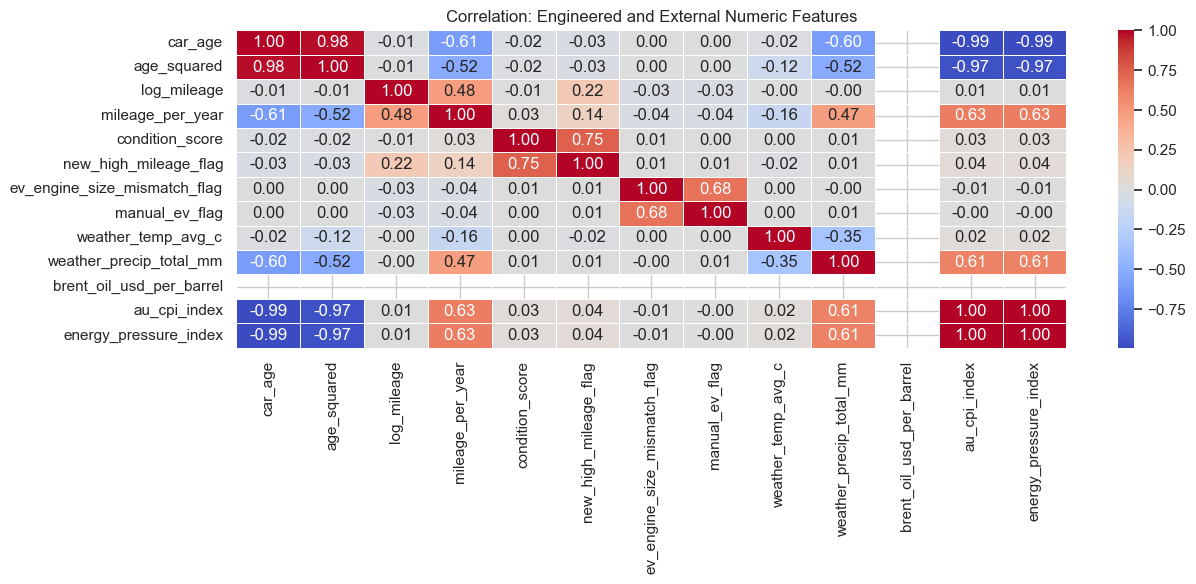

In [17]:
# 7. Feature-quality validation
engineered_cols = [
    'car_age', 'age_squared', 'log_mileage', 'mileage_per_year',
    'condition_score', 'new_high_mileage_flag', 'ev_engine_size_mismatch_flag',
    'manual_ev_flag'
 ]
external_cols = [
    'weather_temp_avg_c', 'weather_precip_total_mm',
    'brent_oil_usd_per_barrel', 'au_cpi_index', 'energy_pressure_index'
 ]
expected_feature_cols = [c for c in engineered_cols + external_cols if c in df_enriched.columns]

missing_pct = (
    df_enriched[expected_feature_cols]
    .isna()
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'index': 'feature', 0: 'missing_pct'})
)
display(missing_pct)

constant_cols = [
    c for c in expected_feature_cols
    if df_enriched[c].nunique(dropna=False) <= 1
]
print('Constant or near-constant features:', constant_cols if constant_cols else 'None')

rule_checks = pd.DataFrame([
    {
        'check': 'new_high_mileage_flag logic',
        'violations': int(df_enriched.loc[
            df_enriched['new_high_mileage_flag'].eq(1) &
            (~df_enriched['Condition'].eq('New') | ~(df_enriched['Mileage'] > 50000))
        ].shape[0])
    },
    {
        'check': 'ev_engine_size_mismatch_flag logic',
        'violations': int(df_enriched.loc[
            df_enriched['ev_engine_size_mismatch_flag'].eq(1) &
            (~df_enriched['Fuel Type'].eq('Electric') | ~(df_enriched['Engine Size'] > 0.1))
        ].shape[0])
    },
    {
        'check': 'manual_ev_flag logic',
        'violations': int(df_enriched.loc[
            df_enriched['manual_ev_flag'].eq(1) &
            (~df_enriched['Fuel Type'].eq('Electric') | ~df_enriched['Transmission'].eq('Manual'))
        ].shape[0])
    }
])
display(rule_checks)

numeric_validate_cols = [
    c for c in expected_feature_cols if pd.api.types.is_numeric_dtype(df_enriched[c])
]
quality_stats = df_enriched[numeric_validate_cols].agg(['min', 'max', 'mean', 'median', 'std']).T
quality_stats['skew'] = df_enriched[numeric_validate_cols].skew()
quality_stats = quality_stats.round(3)
display(quality_stats)

if len(numeric_validate_cols) > 1:
    corr = df_enriched[numeric_validate_cols].corr(numeric_only=True)
    plt.figure(figsize=(max(8, len(corr.columns)), 6))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.4)
    plt.title('Correlation: Engineered and External Numeric Features')
    plt.tight_layout()
    plt.show()

## 8. Export-Ready Enriched Dataset

This step prepares a stable enriched table, writes versioned and latest CSV outputs, and exports feature metadata.

In [18]:
# 8. Build export-ready enriched dataset
from pathlib import Path
from datetime import datetime
import json

if 'engineered_cols' not in globals():
    engineered_cols = [
        'car_age', 'age_squared', 'log_mileage', 'mileage_per_year',
        'condition_score', 'new_high_mileage_flag', 'ev_engine_size_mismatch_flag',
        'manual_ev_flag'
    ]
if 'external_cols' not in globals():
    external_cols = [
        'weather_temp_avg_c', 'weather_precip_total_mm',
        'brent_oil_usd_per_barrel', 'au_cpi_index', 'energy_pressure_index'
    ]

df_export = df_enriched.copy()

# Deterministic imputation for internet columns so exports are model-ready later.
external_fill_cols = [
    'weather_temp_avg_c', 'weather_precip_total_mm',
    'brent_oil_usd_per_barrel', 'au_cpi_index', 'energy_pressure_index'
 ]
for col in external_fill_cols:
    if col in df_export.columns:
        numeric_col = pd.to_numeric(df_export[col], errors='coerce')
        if numeric_col.notna().any():
            df_export[col] = numeric_col.fillna(numeric_col.median())
        else:
            df_export[col] = 0.0

ordered_cols = list(df.columns) + [c for c in df_export.columns if c not in df.columns]
df_export = df_export[ordered_cols]

anchor = Path('car_price_prediction_.csv')
if anchor.exists():
    export_dir = anchor.resolve().parent / 'artifacts'
else:
    export_dir = Path.cwd() / 'Use_Cases' / 'Price Prediction' / 'artifacts'
export_dir.mkdir(parents=True, exist_ok=True)

stamp = datetime.now().strftime('%Y%m%d_%H%M%S')
enriched_versioned_path = export_dir / f'car_price_enriched_{stamp}.csv'
enriched_latest_path = export_dir / 'car_price_enriched_latest.csv'
feature_dict_path = export_dir / 'feature_dictionary.csv'
provenance_path = export_dir / 'source_provenance.json'

df_export.to_csv(enriched_versioned_path, index=False)
df_export.to_csv(enriched_latest_path, index=False)

feature_descriptions = {
    'car_age': 'Vehicle age in years from reference year.',
    'age_squared': 'Non-linear age signal.',
    'log_mileage': 'Log-scaled mileage.',
    'mileage_per_year': 'Mileage normalized by age.',
    'condition_score': 'Ordinal condition score: Used=1, Like New=2, New=3.',
    'new_high_mileage_flag': '1 when condition is New and mileage > 50000.',
    'ev_engine_size_mismatch_flag': '1 when electric vehicle has non-trivial engine size.',
    'manual_ev_flag': '1 when electric vehicle has manual transmission.',
    'weather_temp_avg_c': 'Yearly average temperature proxy (Open-Meteo).',
    'weather_precip_total_mm': 'Yearly total precipitation proxy (Open-Meteo).',
    'brent_oil_usd_per_barrel': 'Yearly average Brent oil price proxy (FRED).',
    'au_cpi_index': 'Australia CPI index proxy (World Bank).',
    'energy_pressure_index': 'Composite z-score of cost pressure proxies.'
 }

feature_sources = {}
for col in df_export.columns:
    if col in df.columns:
        feature_sources[col] = 'original_dataset'
    elif col in engineered_cols:
        feature_sources[col] = 'engineered_internal'
    elif col in external_cols or col == 'energy_pressure_index':
        feature_sources[col] = 'internet_enrichment'
    else:
        feature_sources[col] = 'derived'

feature_dictionary = pd.DataFrame({
    'column': df_export.columns,
    'dtype': [str(df_export[c].dtype) for c in df_export.columns],
    'source': [feature_sources.get(c, 'derived') for c in df_export.columns],
    'missing_pct': [round(df_export[c].isna().mean() * 100, 2) for c in df_export.columns],
    'description': [feature_descriptions.get(c, '') for c in df_export.columns]
})
feature_dictionary.to_csv(feature_dict_path, index=False)

merge_info = merge_diagnostics if 'merge_diagnostics' in globals() else {}
provenance_payload = {
    'generated_at': datetime.now().isoformat(timespec='seconds'),
    'rows': int(df_export.shape[0]),
    'columns': int(df_export.shape[1]),
    'files': {
        'versioned_enriched_csv': str(enriched_versioned_path),
        'latest_enriched_csv': str(enriched_latest_path),
        'feature_dictionary_csv': str(feature_dict_path),
        'provenance_json': str(provenance_path)
    },
    'external_sources': [
        {
            'name': 'Open-Meteo Archive API',
            'url': 'https://archive-api.open-meteo.com/v1/archive',
            'columns': ['weather_temp_avg_c', 'weather_precip_total_mm']
        },
        {
            'name': 'FRED Brent Oil Series',
            'url': 'https://fred.stlouisfed.org/series/DCOILBRENTEU',
            'columns': ['brent_oil_usd_per_barrel']
        },
        {
            'name': 'World Bank AU CPI Indicator',
            'url': 'https://api.worldbank.org/v2/country/AUS/indicator/FP.CPI.TOTL',
            'columns': ['au_cpi_index']
        }
    ],
    'merge_diagnostics': merge_info
}
with open(provenance_path, 'w', encoding='utf-8') as fp:
    json.dump(provenance_payload, fp, indent=2)

print('Export complete.')
print(' - Versioned enriched CSV:', enriched_versioned_path)
print(' - Latest enriched CSV:', enriched_latest_path)
print(' - Feature dictionary:', feature_dict_path)
print(' - Provenance:', provenance_path)

display(df_export.head())
display(feature_dictionary.head(20))

Export complete.
 - Versioned enriched CSV: /home/bala/Documents/EVAT/EVAT-Data-Science/Use_Cases/Price Prediction/artifacts/car_price_enriched_20260422_142127.csv
 - Latest enriched CSV: /home/bala/Documents/EVAT/EVAT-Data-Science/Use_Cases/Price Prediction/artifacts/car_price_enriched_latest.csv
 - Feature dictionary: /home/bala/Documents/EVAT/EVAT-Data-Science/Use_Cases/Price Prediction/artifacts/feature_dictionary.csv
 - Provenance: /home/bala/Documents/EVAT/EVAT-Data-Science/Use_Cases/Price Prediction/artifacts/source_provenance.json


,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model,...,engine_size_bin,condition_mileage_bin,new_high_mileage_flag,ev_engine_size_mismatch_flag,manual_ev_flag,weather_temp_avg_c,weather_precip_total_mm,brent_oil_usd_per_barrel,au_cpi_index,energy_pressure_index
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X,...,small,"New_(71831.5, 149085.0]",1,0,0,15.075683,726.9,0.0,113.475552,0.554460
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series,...,large,"Used_(71831.5, 149085.0]",0,1,1,15.066301,627.4,0.0,117.898023,0.804306
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4,...,large,"New_(149085.0, 225990.5]",1,1,1,15.209041,591.9,0.0,107.700306,0.228189
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y,...,large,"New_(14.999, 71831.5]",1,0,0,14.696712,759.9,0.0,103.303848,-0.020187
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang,...,mid,"Like New_(149085.0, 225990.5]",0,0,0,15.068767,431.6,0.0,97.164415,-0.367032


,column,dtype,source,missing_pct,description
0,Car ID,int64,original_dataset,0.0,
1,Brand,str,original_dataset,0.0,
2,Year,Int64,original_dataset,0.0,
3,Engine Size,float64,original_dataset,0.0,
4,Fuel Type,str,original_dataset,0.0,
5,Transmission,str,original_dataset,0.0,
6,Mileage,int64,original_dataset,0.0,
7,Condition,str,original_dataset,0.0,
8,Price,float64,original_dataset,0.0,
9,Model,str,original_dataset,0.0,


## 9. Final Key Insights

### Data Behavior and EDA Signals
1. Weak linear relationships were observed between Price and core numeric variables (Year, Mileage, Engine Size), so purely linear models are unlikely to capture the price pattern well.
2. Distribution shapes and low outlier prevalence suggest the dataset behaves more like synthetic or heavily constrained data than organic real-world listings.
3. Category-level price distributions overlap substantially across Brand, Fuel Type, Transmission, and Condition, indicating limited standalone pricing power for single categorical variables.
4. Realism anomalies (for example, New vehicles with very high mileage and Manual EV combinations) reinforce the synthetic/randomized nature of the sample.

### Engineered and External Feature Insights
1. Engineered age features are highly redundant: car_age and age_squared are very strongly correlated (about 0.98).
2. External cost-pressure proxies are also highly redundant: au_cpi_index and energy_pressure_index are nearly perfectly correlated (about 1.00).
3. Strong cross-correlation exists between time-trend style variables (age-based features and macro proxies), which increases multicollinearity risk.

### Modeling Implications
1. Prefer non-linear methods (for example Random Forest, Gradient Boosting, or Neural Networks) over plain linear regression for stronger fit.
2. Apply feature selection or regularization before training (for example remove one of car_age/age_squared and one of au_cpi_index/energy_pressure_index) to improve model stability and interpretability.
3. Keep rule-based anomaly flags because they may capture useful interaction signals even when global linear trends are weak.